
<div style="background-color:#5397cbff;padding:20px;border-radius:10px;">
    <h1 style="color:black; text-align:center;">
        ML Project : F1 lap time prediction
    </h1>
    <h3 style="color:black; text-align:center;">
        Model implementation: Random Forest Regressor
    </h3>
    <h5 style="color:black; text-align:center;">
        Elisabeth Cognet, Nour El Khalili, Chatron Emilie -- MMN2
    </h5>
</div>


# Objective: 
The objective of this notebook is to develop a predictive model capable of estimating the fastest lap for each driver in a given Formula 1 race. Using historical F1 race data, the goal is to understand how driver characteristics, performance, and circuit features influence lap times.


#  Target Variable & Type of Problem:
Our target variable is fastestLapTime : it represents he fastest lap time achieved by each driver in a race, expressed in seconds. 
This is a regression problem, since the target variable(fastest lap time) is continuous.
It falls under supervised learning, as the dataset contains labeled examples representing past fastest lap times recorded by drivers.

We will predict the fastest lap time using 3 kind of algorithms :
- Linear models (more preprocessing) -> Ridge, Lasso
- Tree-based models (less preprocessing) -> RandomForest, XGBoost
- End-to-end model (almost no preprocessing) -> CatBoost

For each model, we will use our two datasets, all data (1996-2024) and recent data (2014-2024).The goal is to evaluate the model using all data and then only data from the post-2014 hybrid era, and to compare their performance. Since the introduction of hybrid power units in 2014 marked a major regulatory and technological shift, the seasons after 2014 represent a more homogeneous and stable era of Formula 1. This analysis will help assess whether limiting the training data to this modern, consistent technical environment improves predictive performance compared to using the full multi-era dataset.

PS: all our train and test datasets are complete (no NaN) so we don't need to take care of this part of the preprocessing

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_regression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

#  Some common code and functions for all models:

In [4]:
#all the features we will use for prediction
feature_names = [
    "grid",
    "year",
    "circuitRef",
    "location",
    "trackLength",
    "trackTurns",
    "driverRef",
    "driverNationality",
    "constructorRef",
    "constructorNationality"
]
#we define the categorical and numerical columns here 
#to encode them later depending on the type of model
categorical_cols = [
    "circuitRef",
    "location",
    "driverRef",
    "driverNationality",
    "constructorRef",
    "constructorNationality",
]
numerical_cols = [
    "grid",
    "year",
    "trackLength",
    "trackTurns",
]

## Evaluation functions

In [5]:
#the common function to evaluate a model (compatible with all of our models)
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Train a model, make predictions on the test set,
    and display MAE, RMSE, and R² metrics.

    Parameters:
    - model: an already instantiated sklearn-like model (e.g. RandomForestRegressor())
    - X_train, y_train: training data
    - X_test, y_test: test data
    - model_name: name displayed in the output

    Returns:
    - y_pred: model predictions on X_test
    """

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\nResults for {model_name} :")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    

    return y_pred

In [6]:
#will display agraph with top_n most important features (only for tree-based models)

def plot_feature_importances(model, feature_names, top_n=10):
    """
    Plot the top N feature importances of a fitted tree-based model.

    Parameters:
    - model: trained model with `feature_importances_` attribute 
    - feature_names: list of feature names after preprocessing (one name per column)
    - top_n: number of top features to display (default is 10)
    """

    
    importances = model.feature_importances_
    indices = np.argsort(importances)

    
    top_indices = indices[-top_n:]
    top_features = [feature_names[i] for i in top_indices]
    top_values = importances[top_indices]

    
    plt.figure(figsize=(8, 6))
    plt.barh(top_features, top_values)
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances")
    plt.show()


## Pre-processing pipelines

In [7]:
#pre-processing pipeline basic (only imputation and scaling/encoding)
numeric_transformer_basic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_basic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_basic = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_basic, numerical_cols),
        ("cat", categorical_transformer_basic, categorical_cols),
    ],
    remainder="drop"   
)

In [8]:
#same pre-processing as basic but we add feature selection
preprocess_fs = Pipeline(steps=[
    ("columns", preprocess_basic),
    ("feature_selection", SelectKBest(
        score_func=mutual_info_regression,
        k=50   # we can adjust this if needed
    ))
])


# Linear models

## Ridge (1996-2024)

In [9]:
from sklearn.linear_model import Ridge

In [12]:
X_train = pd.read_csv("data/processed/X_train_all.csv")
X_test = pd.read_csv("data/processed/X_test_all.csv")
y_train = pd.read_csv("data/processed/y_train_all.csv")
y_test = pd.read_csv("data/processed/y_test_all.csv")

y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [13]:
all_X = pd.concat([X_train, X_test], axis=0)

all_X_encoded = pd.get_dummies(
    all_X,
    columns=categorical_cols,
    drop_first=True
)

In [14]:
X_train_enc = all_X_encoded.iloc[:len(X_train)].reset_index(drop=True)
X_test_enc  = all_X_encoded.iloc[len(X_train):].reset_index(drop=True)

scaler = StandardScaler()

X_train_enc[numerical_cols] = scaler.fit_transform(X_train_enc[numerical_cols])
X_test_enc[numerical_cols]  = scaler.transform(X_test_enc[numerical_cols])

In [15]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_enc, y_train)

y_pred_ridge = ridge_model.predict(X_test_enc)

**Analysis of scores**\
These results show that Ridge is able to capture part of the structure in the data, explaining around 55% of the variance in race outcomes. However, the model’s absolute errors remain relatively high: on average, predictions deviate by about 4 positions, which is significant in the context of Formula 1, where small ranking differences are important.

Because Ridge is a linear model, it cannot learn complex interactions between drivers, teams, circuits, or race dynamics. As a consequence, it underperforms compared to more flexible models such as Random Forest or XGBoost, which better capture non-linear patterns.

## Lasso

# Tree-based models

## RandomForest

### Data 1996-2024

In [16]:
X_train = pd.read_csv('data/processed/X_train_all.csv')
X_test = pd.read_csv('data/processed/X_test_all.csv')
y_train = pd.read_csv('data/processed/y_train_all.csv')
y_test = pd.read_csv('data/processed/y_test_all.csv')

In [17]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

Here we convert y from DataFrame to Series, since we're using RandomForestRegressor uses 1D Series

In [19]:
# here we use get_dummies to one-hot encode categorical variables
# we concatenate train and test to ensure consistent encoding
# then we split them back to train and test sets
all_X = pd.concat([X_train, X_test], axis=0)

all_X_encoded = pd.get_dummies(
    all_X,
    columns=categorical_cols,
    drop_first=True
)


X_train_enc = all_X_encoded.iloc[:len(X_train)].reset_index(drop=True)
X_test_enc = all_X_encoded.iloc[len(X_train):].reset_index(drop=True)

X_train_enc.shape, X_test_enc.shape


((8832, 315), (2209, 315))

In [20]:
X_train_enc.dtypes

grid                                  int64
year                                  int64
trackLength                         float64
trackTurns                            int64
circuitRef_americas                    bool
                                     ...   
constructorNationality_Japanese        bool
constructorNationality_Malaysian       bool
constructorNationality_Russian         bool
constructorNationality_Spanish         bool
constructorNationality_Swiss           bool
Length: 315, dtype: object

In [21]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_enc, y_train)          


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [22]:
# train
rf.fit(X_train_enc, y_train)

# predict
y_pred = rf.predict(X_test_enc)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)



MAE: 2.102013988111403
RMSE: 8.37102139336625
R²: 0.6862424342307751


**Analysis of scores:**

These results indicate that the model explains approximately 68.6%  of the variance in the fastest lap time, which a strong baseline given the complexity of F1 performance data.
- MAE means that, on average, the model's predictions deviate by about two seconds from the true fastest lap times.
- RMSE is larger because it penalizes larger prediction errors more heavily. A small number of races with very different conditions, like weather, tire degradation, and track surface can likely contribute to these larger errors.
- R^2 suggests the model captures most of the underlying patterns in the data, though further improvement is possible through better feature representation.


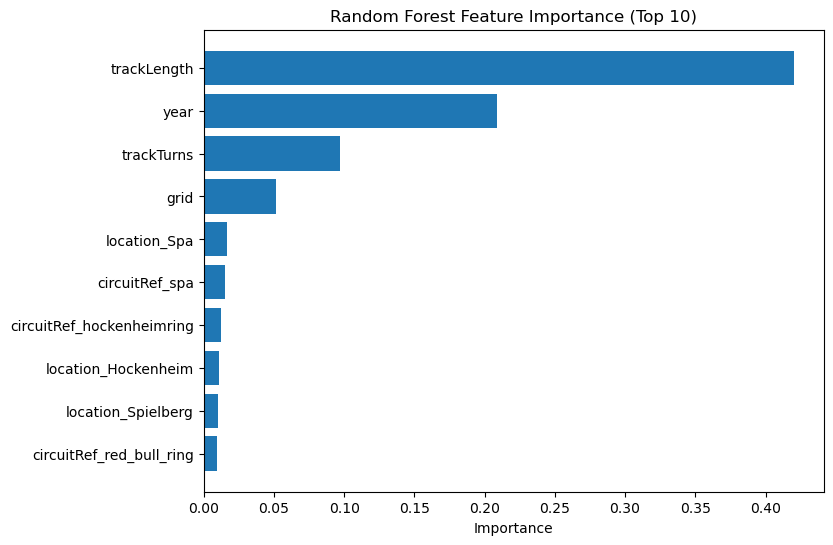

In [23]:
features = X_train_enc.columns

importances = rf.feature_importances_
indices = importances.argsort()
plt.figure(figsize=(8, 6))
plt.barh(features[indices][-10:], importances[indices][-10:]) 
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Top 10)")
plt.show()

**Analysis of feature importance**

The Random Forest model provides a clear and coherent view of the factors that most strongly influence the prediction of fastest lap ties in F1 races. The feature importance raking highlights that track characteristics have the highest explanatory power, followed by temporal effects and competitive context.

1. Track length:
This feature is by far the most influential. Longer circuits naturally produce long lap times, making trackLength a direct determinant of the target variable.

2. Year:
The year of the race captures the evolution of Formula 1 technology and regulations over time. Changes in aerodynamics, power units, tire compounds, and safety requirements affect absolute lap times across eras. Therefore the model correctly identifies this long term trend as a source of variation.

3. Track turns:
The number of corners is also a meaningful predictor. Since circuits with more turns generally lead to slower lap times dude to the reduced straight-line speed and increased braking and acceleration phases. 

4. Grid position:
Although grid position is not directly related to track characteristics, it correlates with underlying performance factors such as car competitiveness and the driver's ability to get the absolute best out of his car. For instance, we know that higher-performing cars (backed up by big teams) typically qualify better and record faster laps (unless it is goat Verstappen, no need for a high performing car). 

5. Circuit-specific and Location specific Variables:
Lastly we have these individual dummy variables derived from categorical encoding that have relatively small but non-negligible impacts. These features capture circuit-specific effects that are not fully represented by length or number of turns, such as altitude, surface type, or layout uniqueness.

### Data 2014-2024

In [24]:
# Load features and target
X_train_14 = pd.read_csv("data/processed/X_train_2014.csv")
X_test_14 = pd.read_csv("data/processed/X_test_2014.csv")
y_train_14 = pd.read_csv("data/processed/y_train_2014.csv")
y_test_14 = pd.read_csv("data/processed/y_test_2014.csv")

# Convert y to a 1D Series
y_train_14 = y_train_14.squeeze()
y_test_14 = y_test_14.squeeze()

X_train_14.shape, X_test_14.shape, y_train_14.shape, y_test_14.shape


((3589, 10), (898, 10), (3589,), (898,))

In [25]:
categorical_cols = [
    "circuitRef",
    "location",
    "driverRef",
    "driverNationality",
    "constructorRef",
    "constructorNationality",
]

# Combine train and test for consistent one-hot encoding
all_X_14 = pd.concat([X_train_14, X_test_14], axis=0)

# One-hot encode categorical cols
all_X_14_encoded = pd.get_dummies(
    all_X_14,
    columns=categorical_cols,
    drop_first=True
)

# Split back into train and test matrices
X_train_14_enc = all_X_14_encoded.iloc[:len(X_train_14)].reset_index(drop=True)
X_test_14_enc = all_X_14_encoded.iloc[len(X_train_14):].reset_index(drop=True)

X_train_14_enc.shape, X_test_14_enc.shape


((3589, 176), (898, 176))

In [26]:
rf_2014 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_2014.fit(X_train_14_enc, y_train_14)


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [27]:
y_pred_14 = rf_2014.predict(X_test_14_enc)

mae_14 = mean_absolute_error(y_test_14, y_pred_14)
rmse_14 = np.sqrt(mean_squared_error(y_test_14, y_pred_14))
r2_14 = r2_score(y_test_14, y_pred_14)

print("Up-to-2014 MAE:", mae_14)
print("Up-to-2014 RMSE:", rmse_14)
print("Up-to-2014 R²:", r2_14)


Up-to-2014 MAE: 1.879204706366883
Up-to-2014 RMSE: 4.77741969621618
Up-to-2014 R²: 0.8950544549623382


**Analysis of scores:**

The model trained on post-2014 data achieves better performance than the model trained on the full multi-era dataset. This improvement can be explained by the increased homogeneity and regulatory stability of the hybrid power unit era introduced in 2014. These things didn't change: 
same 1.6L V6 turbo
same hybrid recovery systems
same fuel flow rules
same battery/MGU-H/MGU-K concepts
same turbo + hybrid interaction
same general aero philosophy

From 2014 onward, Formula 1 experienced fewer major technical disruptions: engine architecture, aerodynamic rules, energy recovery systems, and tire specifications remained relatively consistent across seasons. As a result, the underlying relationships between track characteristics and lap-time performance are more stable and easier for the model to learn.

This comparison highlights an important insight: restricting the dataset to a single, coherent technical era can improve predictive power by reducing structural variability.

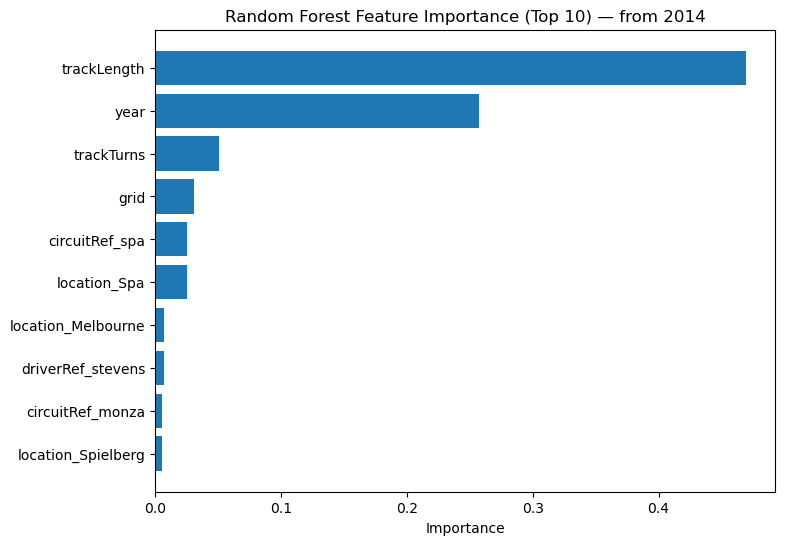

In [28]:
features_2014 = X_train_14_enc.columns
importances_2014 = rf_2014.feature_importances_
indices_2014 = importances_2014.argsort()

plt.figure(figsize=(8,6))
plt.barh(features_2014[indices_2014][-10:], importances_2014[indices_2014][-10:])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Top 10) — from 2014")
plt.show()


**Analysis of important features:**

The feature importance results for the model trained on data from 2014 onward clearly highlight the dominance of track characteristics and temporal progression in determining fastest lap times. Compared with the full historical dataset, the post-2014 shows that the contributing variables did not change.

1. Track Length
Track length is the most influential feature by a significant margin. Longer circuits directly correspond to longer lap times, making this the primary structural determinant of performance.

2. Year
The year variable is the second-most important feature. Even within the hybrid era, gradual advancements in aerodynamics, power unit efficiency, and chassis development continue to influence lap times over time.

3. Track Turns
The number of corners provides a complementary measure of circuit complexity. More turns increase braking and acceleration phases, leading to slower lap times. This feature’s importance confirms that circuit layout influences lap-time variability beyond simple distance.

4. Grid Position
Grid position retains moderate importance. Although not a direct physical attribute of the track, it is correlated with underlying car and driver performance. Teams and drivers with competitive pace tend to qualify higher, which often results in faster lap times during the race.

5. Circuit- and Location-Specific Variables
Several dummy variables related to specific circuits or locations appear among the top contributors, although with much smaller importance values. These variables likely capture residual effects specific to individual circuits—such as elevation, asphalt type, or unique layout elements.

### Conclusion for RandomForest
This study demonstrates that the predictive modeling of Formula 1 fastest lap times is strongly influenced by the temporal scope and technical context of the dataset. Using a Random Forest Regressor, two models were trained and compared: one using the complete historical dataset, and one using only post-2014 hybrid-era data.

Across both models, feature importance analysis consistently highlighted that track-related variables—particularly track length, number of turns, and the year of the race are the dominant determinants of lap time. Grid position and certain circuit-specific characteristics provided secondary but meaningful contributions.

Overall, the results indicate that narrowing the temporal scope to a technical era improves predictive performance, while training on multiple eras introduces variability that reduces model stability. For performance modeling in Formula 1, especially when predicting or understanding lap-time behavior, it is advantageous to analyze data within clearly defined regulatory periods rather than across heterogeneous historical spans.

## XG Boost

In [32]:
pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 7.6 MB/s eta 0:00:10
   - -------------------------------------- 2.1/72.0 MB 5.8 MB/s eta 0:00:13
   - -------------------------------------- 2.9/72.0 MB 5.5 MB/s eta 0:00:13
   -- ------------------------------------- 4.2/72.0 MB 5.4 MB/s eta 0:00:13
   -- ------------------------------------- 5.2/72.0 MB 5.4 MB/s eta 0:00:13
   --- ------------------------------------ 6.6/72.0 MB 5.5 MB/s eta 0:00:12
   ---- ----------------------------------- 7.9/72.0 MB 5.5 MB/s eta 0:00:12
   ----- ---------------------------------- 9.2/72.0 MB 5.7 MB/s eta 0:00:11
   ----- ---------------------------------- 10.5/72.0 MB 5.8 MB/s eta 0:00:11
   ------ --------------------------------- 11.8/72.0 MB 5.8 MB/s eta 0:00:11
   ------- -------------------------------- 12.8/72.0 MB 5.7 MB/s eta 0:00:11
   ------- -------------------------------- 13.9/72.0 MB 5.7 MB/s eta 0:00:11
  

In [33]:
import xgboost as xgb

In [34]:
xgb_model_14 = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1)

In [35]:
y_pred_xgb_14 = evaluate_model(
        xgb_model_14,
        X_train_14_enc,
        y_train_14,
        X_test_14_enc,
        y_test_14,
        model_name="XGBoost Regressor (2014-2024)"
    )


Results for XGBoost Regressor (2014-2024) :
MAE  : 1.9575
RMSE : 4.8671
R²   : 0.8911


**Analysis of the code**   
The XGBoost Regressor provided high accuracy with an $R^2$ of 0.8911, close to the performance of the Random Forest model on the 2014-2024 data. This performance confirms that the gradient boosting approach is as effective as the random forest method.

**Conclusion on Tree-based models**  


# End-to-end model : Cat Boost